# 1.3 With Events Table EDA

Exploratory data analysis for the `eaglei_outages_with_events_*.csv` files.

These tables contain outage events linked to their causing events (e.g., Severe Weather).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load all with_events files (excluding lag files)
data_dir = Path("../../data/raw/introduction/Outage_Dataset")
event_files = [f for f in data_dir.glob("eaglei_outages_with_events_*.csv") 
               if 'lag' not in f.name]

print(f"Found {len(event_files)} with_events files")
for f in sorted(event_files):
    print(f"  - {f.name}")

Found 10 with_events files
  - eaglei_outages_with_events_2014.csv
  - eaglei_outages_with_events_2015.csv
  - eaglei_outages_with_events_2016.csv
  - eaglei_outages_with_events_2017.csv
  - eaglei_outages_with_events_2018.csv
  - eaglei_outages_with_events_2019.csv
  - eaglei_outages_with_events_2020.csv
  - eaglei_outages_with_events_2021.csv
  - eaglei_outages_with_events_2022.csv
  - eaglei_outages_with_events_2023.csv


In [3]:
# Load and combine all event data
dfs = [pd.read_csv(f) for f in event_files]
df = pd.concat(dfs, ignore_index=True)

print(f"Total rows: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Total rows: 526,165

Columns: ['event_id', 'state_event', 'Datetime Event Began', 'Datetime Restoration', 'Event Type', 'fips', 'state', 'county', 'start_time', 'duration', 'end_time', 'min_customers', 'max_customers', 'mean_customers']


,event_id,state_event,Datetime Event Began,Datetime Restoration,Event Type,fips,state,county,start_time,duration,end_time,min_customers,max_customers,mean_customers
0,Alabama-0,Alabama,2015-01-07 17:00:00,2015-01-08 08:35:00,Severe Weather - Winter,1039,Alabama,Covington,2015-01-08 05:00:00,2.00,2015-01-08 07:00:00,723.0,723.0,723.000000
1,Alabama-1,Alabama,2015-02-16 21:00:00,2015-02-18 14:00:00,Severe Weather - Winter,1003,Alabama,Baldwin,2015-02-19 22:15:00,1.00,2015-02-19 23:15:00,368.0,567.0,417.750000
2,Alabama-1,Alabama,2015-02-16 21:00:00,2015-02-18 14:00:00,Severe Weather - Winter,1085,Alabama,Lowndes,2015-02-18 18:45:00,1.25,2015-02-18 20:00:00,405.0,414.0,410.400000
3,Alabama-2,Alabama,2015-02-18 15:00:00,2015-02-20 09:00:00,Severe Weather - Winter,1003,Alabama,Baldwin,2015-02-19 22:15:00,1.00,2015-02-19 23:15:00,368.0,567.0,417.750000
4,Alabama-2,Alabama,2015-02-18 15:00:00,2015-02-20 09:00:00,Severe Weather - Winter,1003,Alabama,Baldwin,2015-02-21 17:45:00,0.75,2015-02-21 18:30:00,312.0,315.0,313.333333


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 526165 entries, 0 to 526164
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   event_id              526165 non-null  str    
 1   state_event           526165 non-null  str    
 2   Datetime Event Began  526165 non-null  str    
 3   Datetime Restoration  526165 non-null  str    
 4   Event Type            526165 non-null  str    
 5   fips                  526165 non-null  int64  
 6   state                 526165 non-null  str    
 7   county                526165 non-null  str    
 8   start_time            526165 non-null  str    
 9   duration              526165 non-null  float64
 10  end_time              526165 non-null  str    
 11  min_customers         526165 non-null  float64
 12  max_customers         526165 non-null  float64
 13  mean_customers        526165 non-null  float64
dtypes: float64(4), int64(1), str(9)
memory usage: 56.2 MB


In [5]:
df.describe()

,fips,duration,min_customers,max_customers,mean_customers
count,526165.000000,526165.000000,526165.000000,5.261650e+05,5.261650e+05
mean,32459.370002,6.147829,2546.468804,5.394324e+03,3.412405e+03
std,16463.601945,13.893502,21891.892151,4.616962e+04,2.601898e+04
min,1001.000000,0.250000,200.000000,2.000000e+02,2.000000e+02
25%,19137.000000,0.500000,226.000000,3.080000e+02,2.856667e+02
50%,36103.000000,1.500000,310.000000,6.440000e+02,5.202917e+02
75%,48201.000000,4.500000,649.000000,1.740000e+03,1.171000e+03
max,56045.000000,331.250000,808450.000000,1.777800e+06,1.078687e+06


## Event Type Frequency

In [6]:
event_type_counts = df['Event Type'].value_counts()
print(f"Unique event types: {len(event_type_counts)}")
event_type_counts

Unique event types: 75


Event Type
Severe Weather                                         390099
System Operations                                       33086
Vandalism                                               22870
Suspicious Activity                                     12650
Transmission Interruption                               11580
                                                        ...  
Electrical System Islanding                                 7
Suspected Cyber Attack                                      6
- Theft - Suspicious activity                               6
Physical Attack                                             4
- Physical attack - Vandalism - Suspicious activity         4
Name: count, Length: 75, dtype: int64

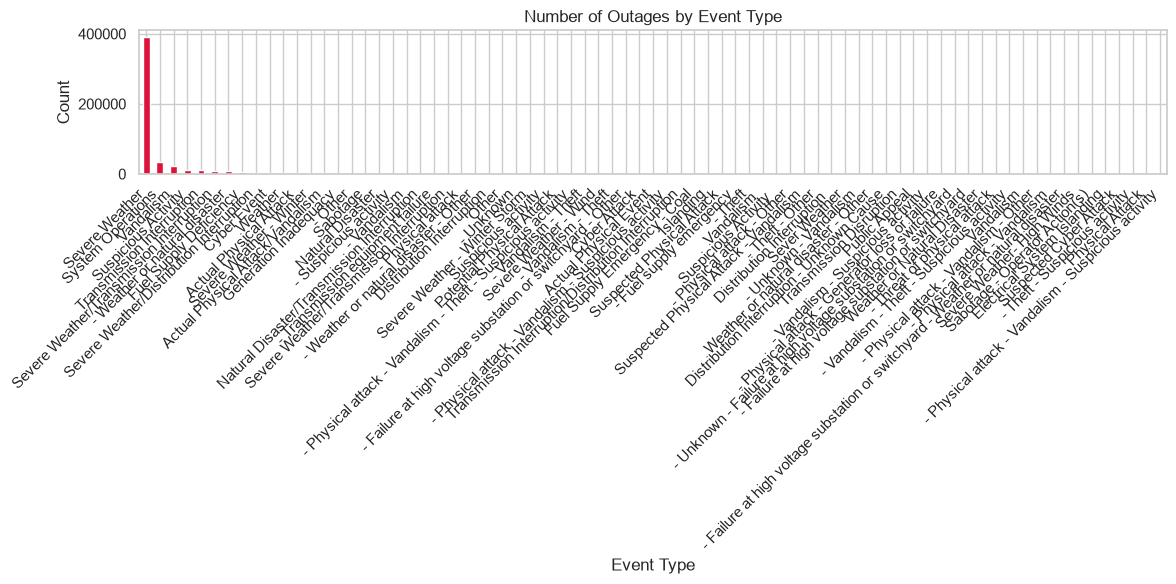

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
event_type_counts.plot(kind='bar', ax=ax, color='crimson')
ax.set_title('Number of Outages by Event Type')
ax.set_xlabel('Event Type')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

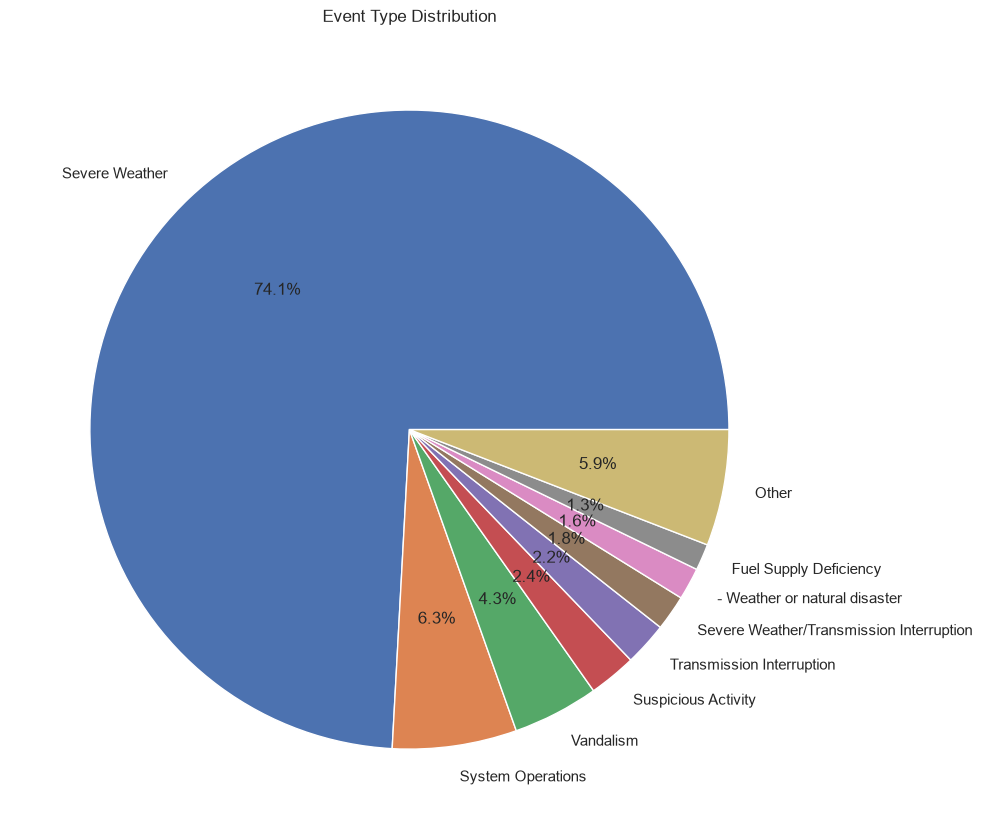


'Other' category includes 67 event types (30,909 events, 5.87%):
  - Severe Weather/Distribution Interruption: 4,079 (0.775%)
  - Cyber Event: 3,027 (0.575%)
  - Weather: 2,832 (0.538%)
  - Actual Physical Attack: 2,435 (0.463%)
  - Severe Weather - Winter: 1,794 (0.341%)
  - Actual Physical Attack/Vandalism: 1,473 (0.280%)
  - Generation Inadequacy: 1,288 (0.245%)
  - - Other: 1,236 (0.235%)
  - Sabotage: 1,131 (0.215%)
  - Natural Disaster: 1,052 (0.200%)
  - - Suspicious activity: 1,036 (0.197%)
  - - Vandalism: 958 (0.182%)
  - Natural Disaster/Transmission Interruption: 664 (0.126%)
  - - Transmission equipment failure: 592 (0.113%)
  - Severe Weather/Transmisison Interruption: 582 (0.111%)
  - - Physical attack: 491 (0.093%)
  - - Weather or natural disaster - Other: 441 (0.084%)
  - Distribution Interruption: 422 (0.080%)
  - Other: 345 (0.066%)
  - - Unknown: 328 (0.062%)
  - Severe Weather - Winter Storm: 286 (0.054%)
  - Suspicious activity: 275 (0.052%)
  - Potential Physic

In [22]:
# Pie chart for event type distribution (grouping <1% into "Other")
total = event_type_counts.sum()
percentages = event_type_counts / total * 100

# Split into main categories (>=1%) and other (<1%)
main_categories = event_type_counts[percentages >= 1]
other_categories = event_type_counts[percentages < 1]

# Create combined series with "Other"
plot_data = main_categories.copy()
if len(other_categories) > 0:
    plot_data['Other'] = other_categories.sum()

fig, ax = plt.subplots(figsize=(10, 10))
plot_data.plot(kind='pie', ax=ax, autopct='%1.1f%%')
ax.set_title('Event Type Distribution')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Print categories that make up "Other"
if len(other_categories) > 0:
    print(f"\n'Other' category includes {len(other_categories)} event types ({other_categories.sum():,} events, {other_categories.sum()/total*100:.2f}%):")
    for event_type, count in other_categories.items():
        print(f"  - {event_type}: {count:,} ({count/total*100:.3f}%)")

## Event ID Frequency

In [9]:
event_id_counts = df['event_id'].value_counts()
print(f"Unique event IDs: {len(event_id_counts)}")
print(f"\nTop 10 events by number of outages:")
event_id_counts.head(10)

Unique event IDs: 663

Top 10 events by number of outages:


event_id
Texas-9       22663
Texas-10      21823
Texas-7       16005
Florida-4     14831
Michigan-2    14610
Florida-5     13632
Michigan-3    12412
Texas-42      12168
Michigan-4    10992
Kentucky-6     7865
Name: count, dtype: int64

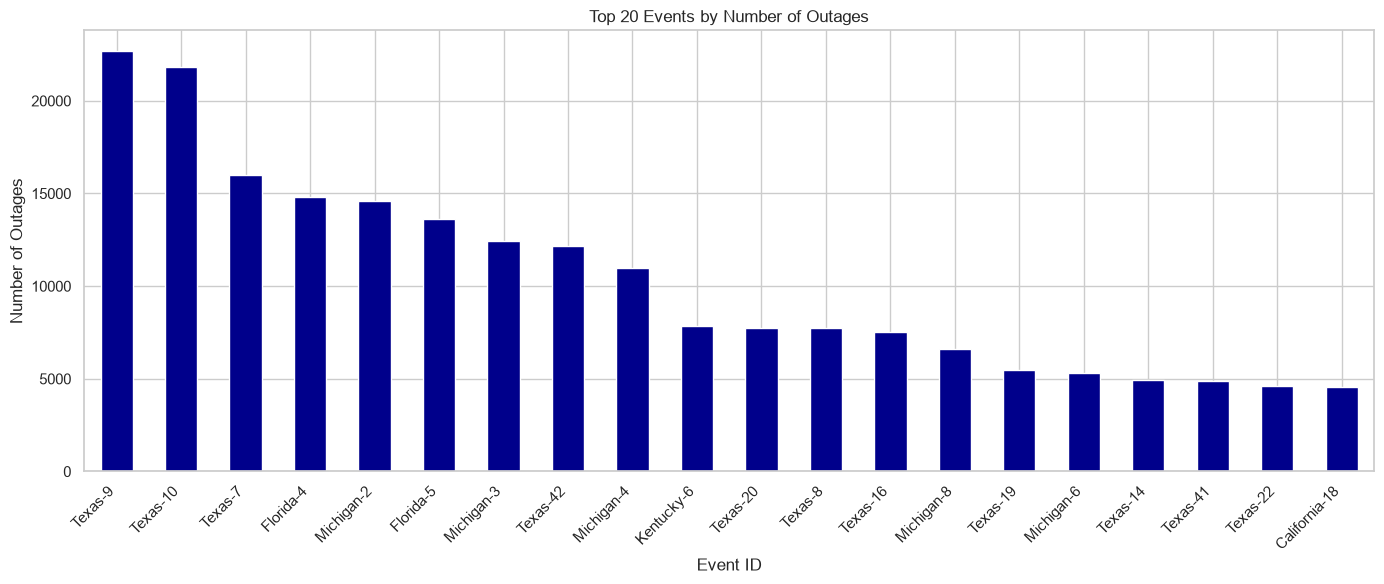

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
event_id_counts.head(20).plot(kind='bar', ax=ax, color='darkblue')
ax.set_title('Top 20 Events by Number of Outages')
ax.set_xlabel('Event ID')
ax.set_ylabel('Number of Outages')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## State Frequency

In [11]:
state_counts = df['state'].value_counts()
print(f"Unique states: {len(state_counts)}")
state_counts.head(10)

Unique states: 48


state
Texas             196347
Michigan           72764
California         61499
Florida            39338
New York           13222
North Carolina     11470
Pennsylvania       10766
Kentucky           10689
Louisiana           9326
Washington          7838
Name: count, dtype: int64

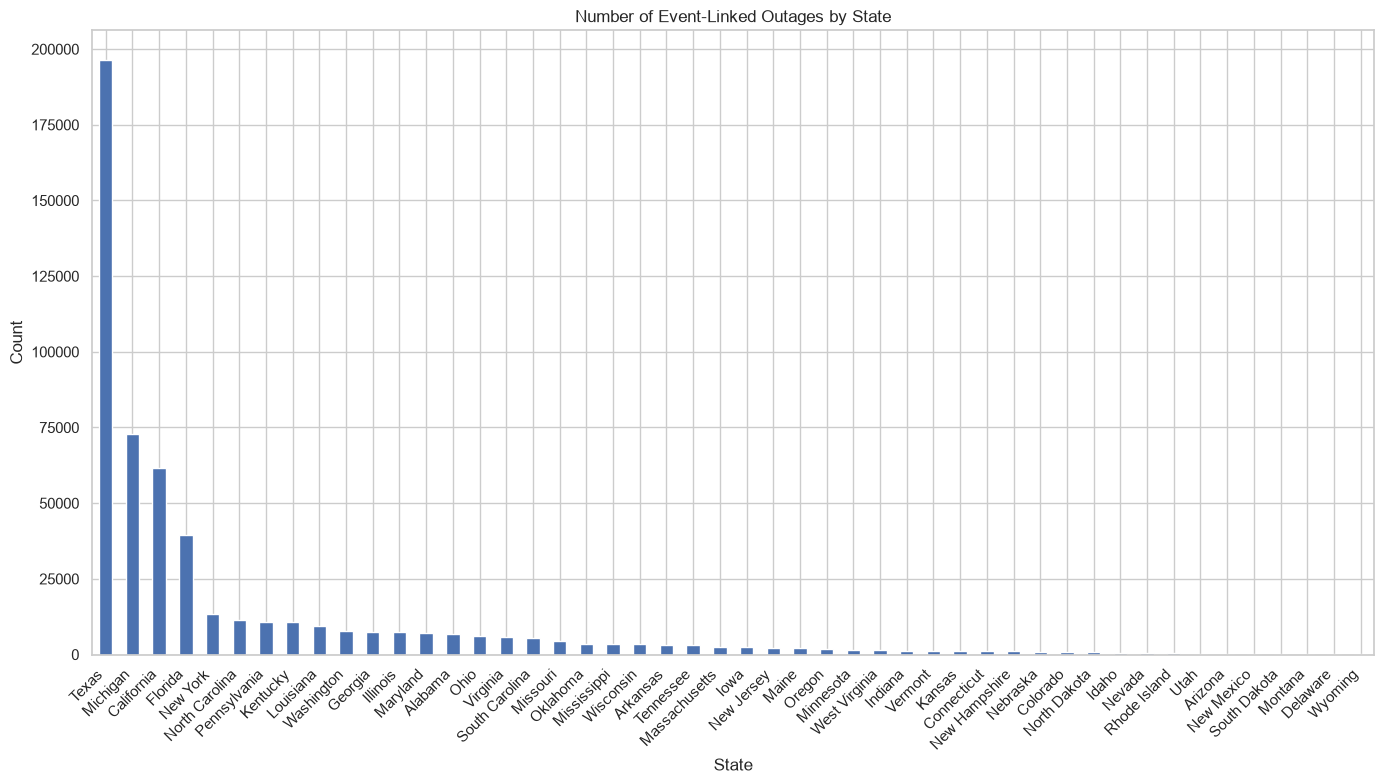

In [12]:
fig, ax = plt.subplots(figsize=(14, 8))
state_counts.plot(kind='bar', ax=ax)
ax.set_title('Number of Event-Linked Outages by State')
ax.set_xlabel('State')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## County Frequency (Top 20)

In [13]:
county_counts = df['county'].value_counts()
print(f"Unique counties: {len(county_counts)}")
county_counts.head(20)

Unique counties: 1675


county
Harris            7308
Montgomery        7128
Orange            6383
Dallas            6127
Tarrant           5886
Baltimore         5791
Brazoria          5252
Fort Bend         5185
Jefferson         4653
Rains             4268
Wayne             3956
Bexar             3827
Riverside         3622
Lee               3581
Fayette           3417
San Bernardino    3236
Galveston         3188
Waller            3183
Monroe            3148
Wharton           3112
Name: count, dtype: int64

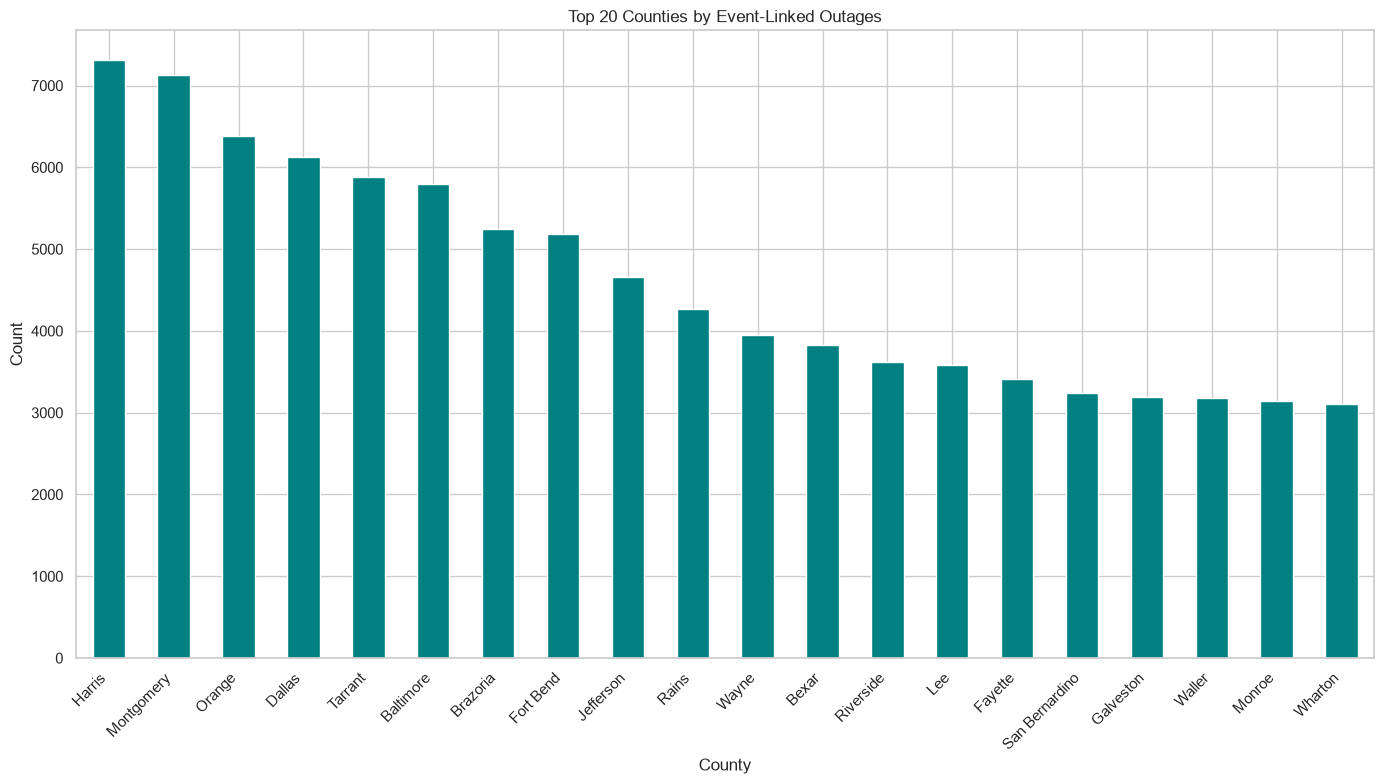

In [14]:
fig, ax = plt.subplots(figsize=(14, 8))
county_counts.head(20).plot(kind='bar', ax=ax, color='teal')
ax.set_title('Top 20 Counties by Event-Linked Outages')
ax.set_xlabel('County')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Duration Distribution

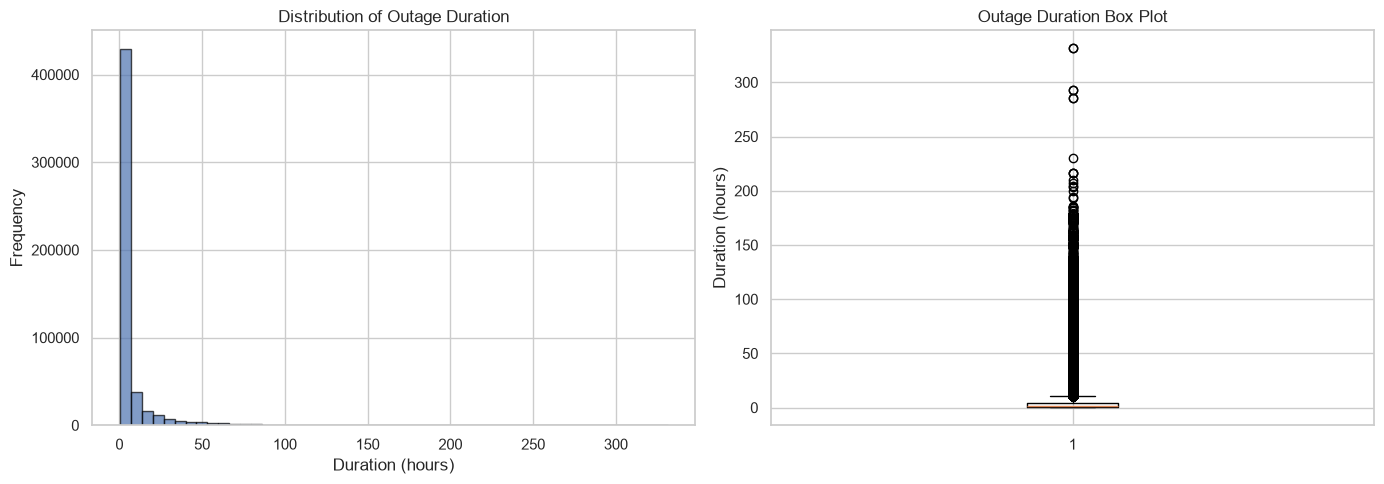

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['duration'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Outage Duration')
axes[0].set_xlabel('Duration (hours)')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['duration'].dropna())
axes[1].set_title('Outage Duration Box Plot')
axes[1].set_ylabel('Duration (hours)')

plt.tight_layout()
plt.show()

## Max Customers Distribution

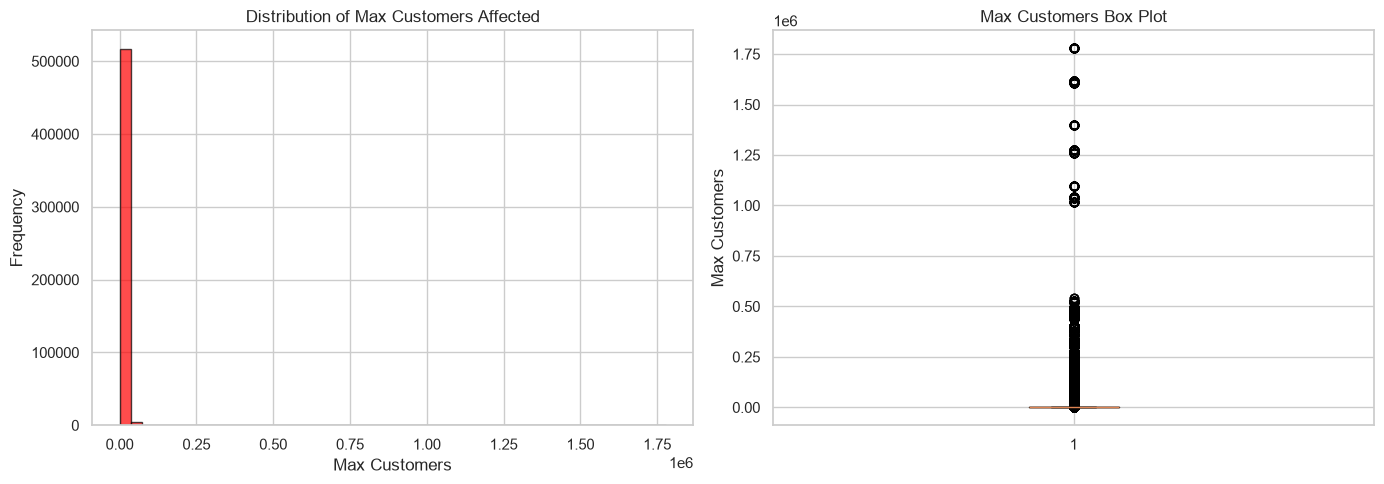

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['max_customers'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[0].set_title('Distribution of Max Customers Affected')
axes[0].set_xlabel('Max Customers')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['max_customers'].dropna())
axes[1].set_title('Max Customers Box Plot')
axes[1].set_ylabel('Max Customers')

plt.tight_layout()
plt.show()

## Temporal Analysis

In [17]:
# Parse datetime
df['start_time'] = pd.to_datetime(df['start_time'])
df['year'] = df['start_time'].dt.year
df['month'] = df['start_time'].dt.month

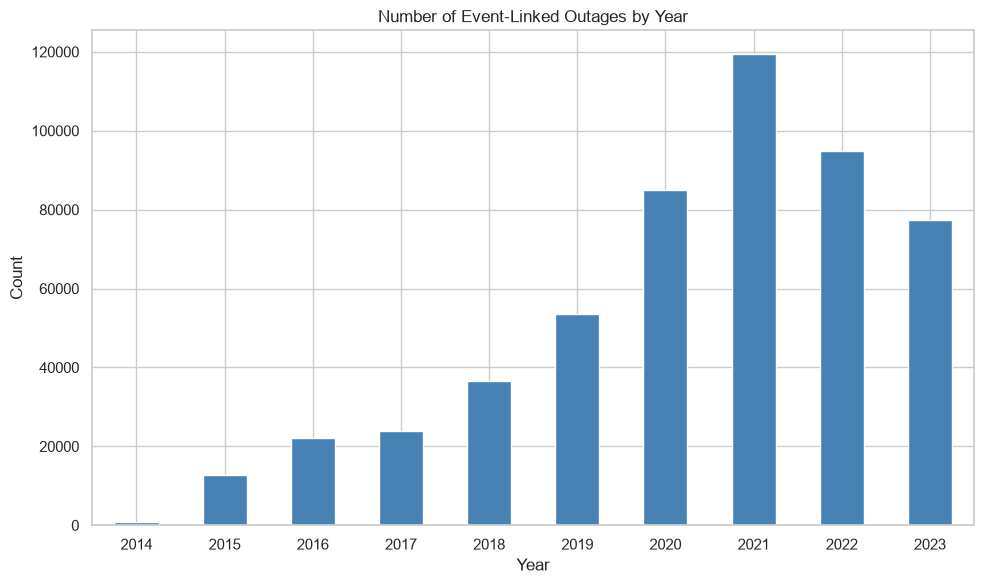

In [18]:
year_counts = df['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
year_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Number of Event-Linked Outages by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

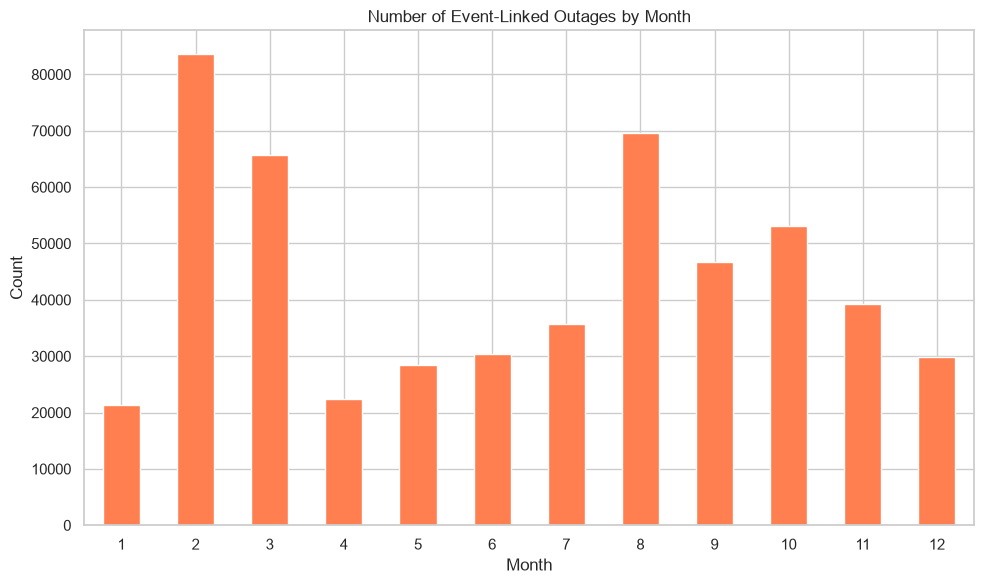

In [19]:
month_counts = df['month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
month_counts.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Number of Event-Linked Outages by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Event Type by State

In [20]:
# Cross-tabulation of event types by state
event_state_crosstab = pd.crosstab(df['state'], df['Event Type'])
event_state_crosstab.head(10)

Event Type,Vandalism,- Failure at high voltage substation or switchyard,- Failure at high voltage substation or switchyard - Other,- Failure at high voltage substation or switchyard - Weather or natural disaster,- Fuel supply emergency,- Other,- Physical attack,- Physical attack - Generator loss or failure,- Physical attack - Other,- Physical attack - Vandalism - Suspicious activity,...,Suspicious activity,System Operations,Transmission Disruption,Transmission Interruption,Transmission Interruption/Distribution Interruption,Vandalism,Vandalism,Weather,Weather or Natural Disaster,Weather or natural disaster - Other
state,,,,,,,,,,,,,,,,,,,,,
Alabama,0,0,0,0,0,0,0,0,0,0,...,38,24,0,144,0,239,0,25,0,0
Arizona,0,0,0,0,0,0,0,0,0,0,...,0,123,0,22,0,16,0,0,0,0
Arkansas,0,0,0,0,0,0,0,0,0,0,...,0,273,0,236,0,91,0,0,0,0
California,0,0,0,0,131,193,0,0,0,0,...,122,10657,60,851,0,9661,0,0,0,0
Colorado,0,0,0,0,0,25,0,0,0,0,...,0,54,0,298,0,112,0,88,0,0
Connecticut,0,0,0,0,0,0,0,0,0,0,...,0,11,0,0,0,0,0,68,0,0
Delaware,0,0,0,0,0,0,0,0,0,0,...,0,4,0,0,0,25,0,0,0,0
Florida,0,0,0,0,0,147,0,0,0,0,...,0,1663,0,968,0,1287,0,132,0,0
Georgia,0,0,0,0,0,0,0,0,0,0,...,0,110,0,0,0,514,0,114,0,0


/var/folders/rf/67rlpxv97rn3kj1ypyqy5k9c0000gn/T/ipykernel_51902/2920098817.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


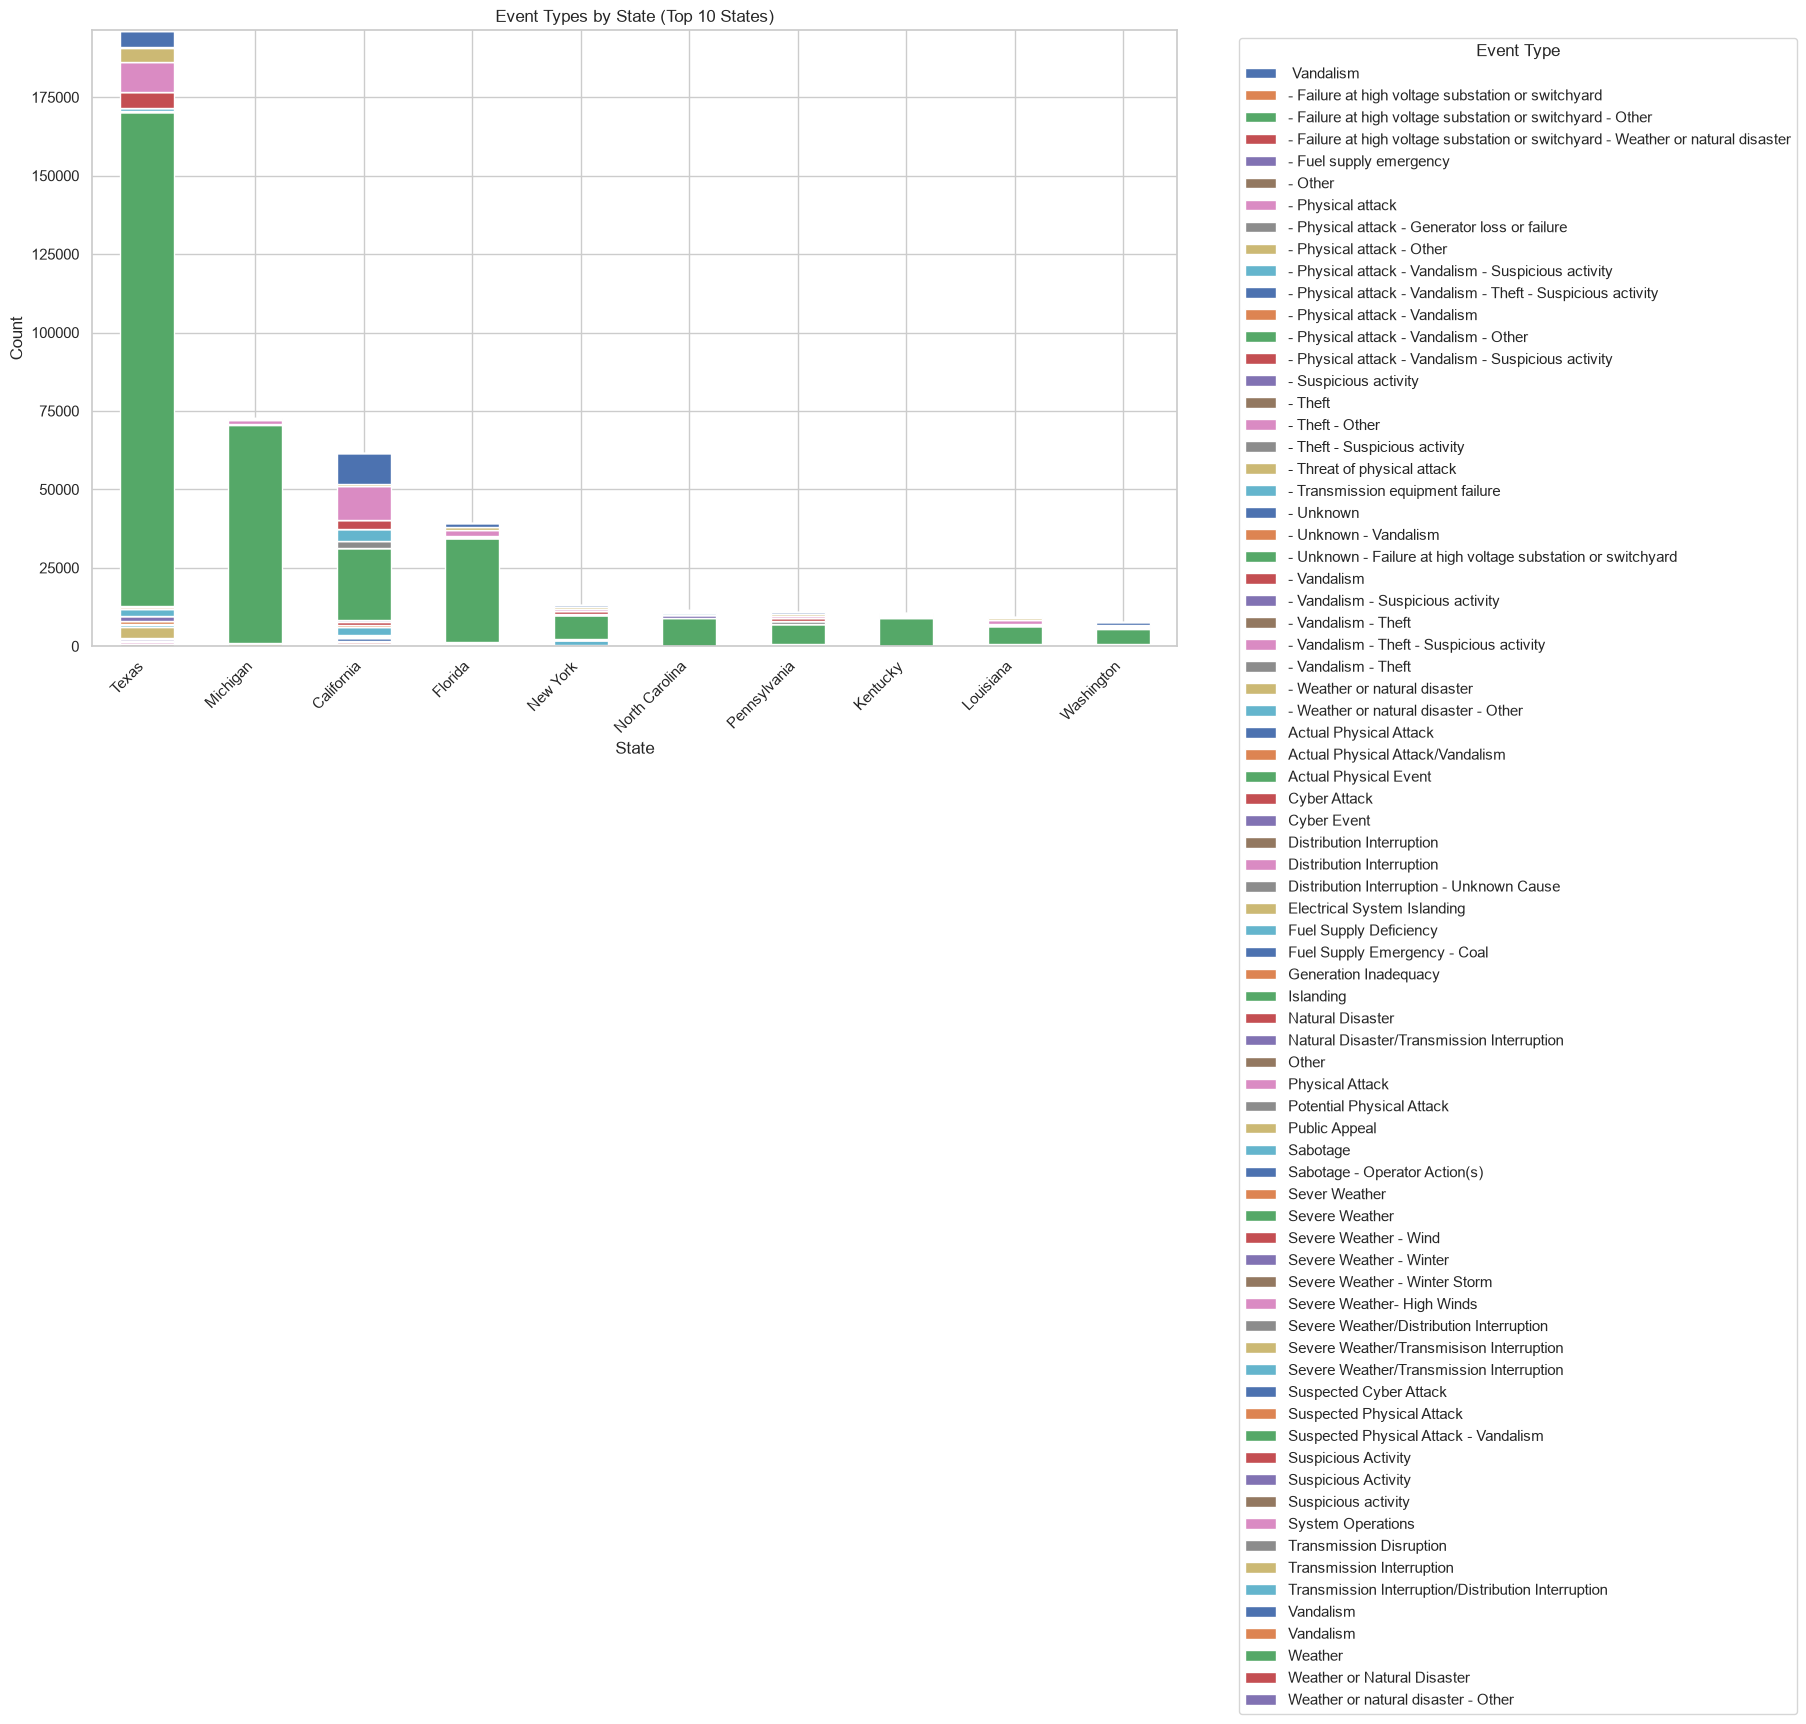

In [21]:
# Top 10 states by total outages, showing event type breakdown
top_states = state_counts.head(10).index
top_state_events = event_state_crosstab.loc[top_states]

fig, ax = plt.subplots(figsize=(14, 8))
top_state_events.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Event Types by State (Top 10 States)')
ax.set_xlabel('State')
ax.set_ylabel('Count')
ax.legend(title='Event Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()